---
title: "Generating your own travel time matrices"
image: image.png
toc: true
execute: 
  enabled: false
---

There are a wide range of options for generating your own travel time matrices, including various travel time APIs. 

You can find an example of how to use the routingpy package, which supports a wide range of APIs, here: https://geographic.hsma.co.uk/mtt_travel_time_apis.html

One good way is the r5py package. 

This takes an output from the open street map project as well as bus and light rail (e.g. tram) public tranport data in the gtfs format. 

OSM data: https://download.geofabrik.de/europe/united-kingdom/england.html

UK Bus/light rail Data: https://data.bus-data.dft.gov.uk/search/

(at the time of writing, heavy rail data is a bit more of a challenge!)

Because you're running this locally, you aren't contending with the number of requests you can make to the online services (API rate limits). Some free services like the openrouteservice don't provide public transport routing support by default either. 



:::{.callout-tip}
If you're comfortable with the R language, you might also find the [UK2GTFS](https://itsleeds.github.io/UK2GTFS/) package useful
:::

:::{.callout-warning}
One limitation of r5py is that it requires the install of a JDK. This may be challenging if you are working in an organisation and your IT department has concerns about Java. 

One option may be to use a service like GitHub codespaces to install the required software - a tutorial on this will be released at a later date. 
:::

We'll kick off with a couple of standard imports. 

In [1]:
import datetime
import pandas as pd
import geopandas

Let's start by importing our data to set up a transport network. 

In [2]:
import r5py

transport_network = r5py.TransportNetwork(
    "../../datasets/devon-260422.osm.pbf",
    [
        "../../datasets/itm_south_west_gtfs.zip",
    ]
)

Let's then read in a dataset of destinations - in this case, minor injury units in Devon. 

In [3]:
devon_mius = pd.read_csv("../../datasets/devon_miu.csv")
devon_mius

,Facility_Name,Latitude,Longitude
0,North Devon District Hospital,51.09217,-4.05043
1,Honiton Hospital,50.79492,-3.18659
2,Tiverton & District Hospital,50.90933,-3.49308
3,Exmouth Minor Injury Unit,50.62083,-3.40198
4,Victoria Hospital (Sidmouth),50.68161,-3.23966
5,Newton Abbot Community Hospital,50.53926,-3.61224
6,Totnes Community Hospital,50.43283,-3.68406
7,NHS Walk in Centre (Exeter),50.72658,-3.52521
8,Tavistock Hospital,50.54708,-4.15376
9,South Hams Hospital (Kingsbridge),50.28929,-3.78143


Let's turn this into a geodataframe. 

In [4]:
devon_mius_gdf = geopandas.GeoDataFrame(
    devon_mius,
    geometry = geopandas.points_from_xy(
        devon_mius['Longitude'],
        devon_mius['Latitude']
        ),
    crs = 'EPSG:4326'
    )

devon_mius_gdf

,Facility_Name,Latitude,Longitude,geometry
0,North Devon District Hospital,51.09217,-4.05043,POINT (-4.05043 51.09217)
1,Honiton Hospital,50.79492,-3.18659,POINT (-3.18659 50.79492)
2,Tiverton & District Hospital,50.90933,-3.49308,POINT (-3.49308 50.90933)
3,Exmouth Minor Injury Unit,50.62083,-3.40198,POINT (-3.40198 50.62083)
4,Victoria Hospital (Sidmouth),50.68161,-3.23966,POINT (-3.23966 50.68161)
5,Newton Abbot Community Hospital,50.53926,-3.61224,POINT (-3.61224 50.53926)
6,Totnes Community Hospital,50.43283,-3.68406,POINT (-3.68406 50.43283)
7,NHS Walk in Centre (Exeter),50.72658,-3.52521,POINT (-3.52521 50.72658)
8,Tavistock Hospital,50.54708,-4.15376,POINT (-4.15376 50.54708)
9,South Hams Hospital (Kingsbridge),50.28929,-3.78143,POINT (-3.78143 50.28929)


We can save this out for easier reuse too. 

In [ ]:
devon_mius_gdf.to_file("../../../sample_data/devon_mius.geojson", driver="GeoJSON")

For using this with r5py, we'll need to rename our 'Facility_Name' column to 'id'. 

In [6]:
devon_mius_gdf = devon_mius_gdf.rename(columns={'Facility_Name':'id'})
devon_mius_gdf.head(2)

,id,Latitude,Longitude,geometry
0,North Devon District Hospital,51.09217,-4.05043,POINT (-4.05043 51.09217)
1,Honiton Hospital,50.79492,-3.18659,POINT (-3.18659 50.79492)


Let's just have a quick look at these on the map. 

In [7]:
devon_mius_gdf.explore()

Now we need to grab our sources (where our patients will travel from). We'll use LSOA centroids for this. 

In [8]:
lsoa_centroids = pd.read_csv(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/england_lsoa_2011_centroids.csv"
    )


In [9]:
lsoa_centroids.head()

,name,code,x,y
0,Middlesbrough 012A,E01012007,449119.175,517017.509
1,Middlesbrough 010D,E01012085,451722.550,517577.735
2,Hartlepool 014G,E01012005,448657.056,533984.633
3,Middlesbrough 010C,E01012084,451977.348,517832.468
4,Hartlepool 006D,E01012002,449565.447,533268.699


To sense check our filtering, though, we'll take a look at an LSOA boundary file, which contains the LSOA names in the same format. The 'name' column in our centroids file is the same as the LSOA11NM in the boundaries geodataframe.  

In [10]:
lsoa_boundaries = geopandas.read_file(
    "https://github.com/hsma-programme/h6_3c_interactive_plots_travel/raw/main/h6_3c_interactive_plots_travel/example_code/LSOA_2011_Boundaries_Super_Generalised_Clipped_BSC_EW_V4.geojson"
    )

In [11]:
lsoa_boundaries.head()

,FID,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E01000001,City of London 001A,City of London 001A,532123,181632,-0.097140,51.51816,a758442e-7679-45d0-95a8-ed4c968ecdaa,"POLYGON ((532282.629 181906.496, 532248.25 181..."
1,2,E01000002,City of London 001B,City of London 001B,532480,181715,-0.091970,51.51882,861dbb53-dfaf-4f57-be96-4527e2ec511f,"POLYGON ((532746.814 181786.892, 532248.25 181..."
2,3,E01000003,City of London 001C,City of London 001C,532239,182033,-0.095320,51.52174,9f765b55-2061-484a-862b-fa0325991616,"POLYGON ((532293.068 182068.422, 532419.592 18..."
3,4,E01000005,City of London 001E,City of London 001E,533581,181283,-0.076270,51.51468,a55c4c31-ef1c-42fc-bfa9-07c8f2025928,"POLYGON ((533604.245 181418.129, 533743.689 18..."
4,5,E01000006,Barking and Dagenham 016A,Barking and Dagenham 016A,544994,184274,0.089317,51.53875,9cdabaa8-d9bd-4a94-bb3b-98a933ceedad,"POLYGON ((545271.918 184183.948, 545296.314 18..."


:::{.callout-tip}
We could also use a geopandas function to get centroids from our boundary dataframe! 

We might also want to look for an option like population-weighted centroids. 
:::

:::{.callout-note}
We may also need to consider looking at smaller units of area, particularly if we're interested in options like public transport or walking, as LSOAs can cover a vast area compared to something like a postcode sector. However, for the sake of this example, we're going to stick with LSOAs. 
:::

Let's try out our filter and confirm we've correctly filtered by all the right LSOA names. 

<Axes: >

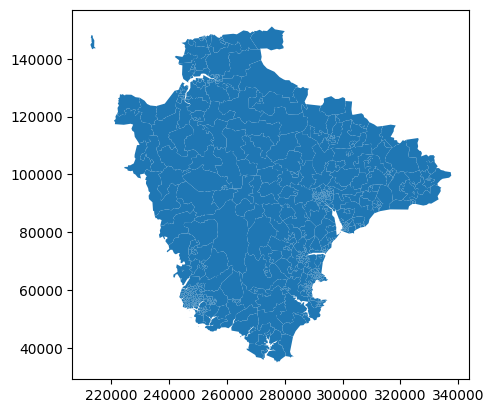

In [12]:
lsoa_boundaries[lsoa_boundaries["LSOA11NM"].str.contains(
    "Devon|Torbay|South Hams|Exeter|Torridge|Teignbridge|Plymouth"
    )].plot()

We can also take a look on an interactive plot. 

In [13]:
lsoa_boundaries[lsoa_boundaries["LSOA11NM"].str.contains(
    "Devon|Torbay|South Hams|Exeter|Torridge|Teignbridge|Plymouth"
    )].explore()

Let's now turn this into a geodataframe and convert it from BNH (Northings/Eastings) to latitude and longitude to match our other data (and what r5py expects). 

In [14]:
devon_lsoas_with_coords = lsoa_centroids[lsoa_centroids["name"].str.contains(
    "Devon|Torbay|South Hams|Exeter|Torridge|Teignbridge|Plymouth"
    )]

devon_lsoas_with_coords_gdf = geopandas.GeoDataFrame(
    devon_lsoas_with_coords,
    geometry = geopandas.points_from_xy(
        devon_lsoas_with_coords['x'],
        devon_lsoas_with_coords['y']
        ),
    crs = 'EPSG:27700' # as our current dataset is in BNG (northings/eastings)
    ).to_crs('EPSG:4326').rename(columns={'name':'id'})

devon_lsoas_with_coords_gdf

,id,code,x,y,geometry
29583,Torbay 006C,E01015216,292132.142,64632.566,POINT (-3.52139 50.47156)
29585,Torbay 008A,E01015217,291749.626,64295.856,POINT (-3.52668 50.46846)
29587,Torbay 006A,E01015214,291750.141,64630.567,POINT (-3.52677 50.47147)
29589,Torbay 006B,E01015215,292381.278,64581.160,POINT (-3.51787 50.47115)
29591,Torbay 019C,E01015212,290286.739,64323.402,POINT (-3.54729 50.46844)
...,...,...,...,...,...
32825,East Devon 005B,E01019887,329961.723,98655.512,POINT (-2.99485 50.78323)
32828,Torbay 017A,E01015183,292872.985,55875.060,POINT (-3.50845 50.39297)
32829,Torbay 017G,E01015189,292320.564,56248.741,POINT (-3.51632 50.39623)
32833,Torridge 008B,E01020293,234408.086,104233.376,POINT (-4.35192 50.81392)


## Generating the matrix

### Car travel 

In [15]:
travel_time_matrix_car = r5py.TravelTimeMatrix(
    transport_network,
    origins=devon_lsoas_with_coords_gdf,
    destinations=devon_mius_gdf,
    transport_modes=[r5py.TransportMode.CAR],
    departure=datetime.datetime(2026, 4, 23, 14, 0, 0),
)

In [16]:
travel_time_matrix_car

,from_id,to_id,travel_time
0,Torbay 006C,North Devon District Hospital,94.0
1,Torbay 006C,Honiton Hospital,47.0
2,Torbay 006C,Tiverton & District Hospital,51.0
3,Torbay 006C,Exmouth Minor Injury Unit,44.0
4,Torbay 006C,Victoria Hospital (Sidmouth),49.0
...,...,...,...
10600,Plymouth 014C,Cumberland Centre (Plymouth),7.0
10601,Plymouth 014C,Derriford Hospital (UTC),11.0
10602,Plymouth 014C,Ilfracombe & District Tyrrell Hospital,NaN
10603,Plymouth 014C,South Molton Hospital,90.0


This isn't in the format lokigi expects - we just need to turn it into a wide format dataframe, where we have one row per source (where our patients will travel from) and one column per destination (where they might turn up to). 

In [17]:
travel_time_matrix_car_wide = travel_time_matrix_car.pivot(columns="to_id", index="from_id", values="travel_time").reset_index()
travel_time_matrix_car_wide

to_id,from_id,Cumberland Centre (Plymouth),Dawlish Community Hospital,Derriford Hospital (UTC),Exmouth Minor Injury Unit,Honiton Hospital,Ilfracombe & District Tyrrell Hospital,NHS Walk in Centre (Exeter),Newton Abbot Community Hospital,North Devon District Hospital,South Hams Hospital (Kingsbridge),South Molton Hospital,Tavistock Hospital,Tiverton & District Hospital,Totnes Community Hospital,Victoria Hospital (Sidmouth)
0,East Devon 001A,75.0,44.0,70.0,38.0,16.0,86.0,35.0,47.0,77.0,71.0,55.0,72.0,34.0,56.0,29.0
1,East Devon 001B,71.0,40.0,66.0,33.0,12.0,92.0,31.0,43.0,83.0,67.0,61.0,67.0,40.0,52.0,27.0
2,East Devon 001C,83.0,52.0,77.0,45.0,25.0,104.0,43.0,55.0,94.0,79.0,72.0,79.0,52.0,64.0,39.0
3,East Devon 002A,67.0,36.0,61.0,29.0,3.0,84.0,27.0,39.0,75.0,63.0,53.0,63.0,33.0,48.0,19.0
4,East Devon 002B,67.0,36.0,61.0,29.0,5.0,82.0,27.0,39.0,73.0,63.0,51.0,63.0,30.0,48.0,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,West Devon 006D,27.0,67.0,16.0,70.0,73.0,103.0,60.0,52.0,90.0,52.0,84.0,11.0,77.0,45.0,75.0
703,West Devon 007A,34.0,74.0,23.0,77.0,81.0,110.0,68.0,60.0,97.0,60.0,92.0,16.0,85.0,52.0,83.0
704,West Devon 007B,34.0,74.0,24.0,76.0,80.0,110.0,67.0,60.0,96.0,60.0,91.0,15.0,84.0,52.0,82.0
705,West Devon 007C,29.0,69.0,18.0,74.0,78.0,109.0,67.0,54.0,96.0,54.0,91.0,17.0,82.0,47.0,79.0


:::{.callout-note}
r5py assumes free flowing traffic at the speed limit - so this might not be overly realistic for traffic! 
:::

Lokigi can't handle missing values in a travel matrix, which might exist here if the time between any two points is over 2 hours or otherwise deemed to be impossible, so let's fill any missing values with a very large travel time. 

In [18]:
travel_time_matrix_car_wide = travel_time_matrix_car_wide.fillna(9999.0)

We can save this to a csv for convenience if we want to load it in elsewhere later.

In [19]:
travel_time_matrix_car_wide.to_csv("../../../sample_data/devon_miu_travel_matrix.csv", index=False)

### Public transport

For public transport, we change our transport mode to TRANSIT.

By default, it assumes people can walk to where they will pick up their journey with public transport. 

In [20]:
travel_time_matrix_transit = r5py.TravelTimeMatrix(
    transport_network,
    origins=devon_lsoas_with_coords_gdf,
    destinations=devon_mius_gdf,
    transport_modes=[r5py.TransportMode.TRANSIT],
    departure=datetime.datetime(2026, 4, 23, 14, 0, 0),
)

Let's first just filter down to instances where it's successfully computed a time. 

In [21]:
travel_time_matrix_transit[~travel_time_matrix_transit["travel_time"].isna()]

,from_id,to_id,travel_time
5,Torbay 006C,Newton Abbot Community Hospital,78.0
6,Torbay 006C,Totnes Community Hospital,97.0
14,Torbay 006C,Dawlish Community Hospital,114.0
20,Torbay 008A,Newton Abbot Community Hospital,70.0
21,Torbay 008A,Totnes Community Hospital,79.0
...,...,...,...
10551,Torbay 017A,Totnes Community Hospital,82.0
10566,Torbay 017G,Totnes Community Hospital,77.0
10598,Plymouth 014C,Tavistock Hospital,83.0
10600,Plymouth 014C,Cumberland Centre (Plymouth),25.0


Now let's make a wide version of this too. 

In [22]:
travel_time_matrix_transit_wide = travel_time_matrix_transit.pivot(columns="to_id", index="from_id", values="travel_time").reset_index()
travel_time_matrix_transit_wide

to_id,from_id,Cumberland Centre (Plymouth),Dawlish Community Hospital,Derriford Hospital (UTC),Exmouth Minor Injury Unit,Honiton Hospital,Ilfracombe & District Tyrrell Hospital,NHS Walk in Centre (Exeter),Newton Abbot Community Hospital,North Devon District Hospital,South Hams Hospital (Kingsbridge),South Molton Hospital,Tavistock Hospital,Tiverton & District Hospital,Totnes Community Hospital,Victoria Hospital (Sidmouth)
0,East Devon 001A,NaN,NaN,NaN,NaN,101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,East Devon 001B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,East Devon 001C,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,East Devon 002A,NaN,NaN,NaN,NaN,14.0,NaN,86.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0
4,East Devon 002B,NaN,NaN,NaN,NaN,18.0,NaN,82.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,West Devon 006D,83.0,NaN,51.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,41.0,NaN,NaN,NaN
703,West Devon 007A,NaN,NaN,113.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,NaN,NaN,NaN
704,West Devon 007B,NaN,NaN,113.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,NaN,NaN,NaN
705,West Devon 007C,NaN,NaN,87.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,80.0,NaN,NaN,NaN


There are a lot of NAs this time! 

Let's again fill this for any instances with impossibly long travel times.

In [23]:
travel_time_matrix_transit_wide = travel_time_matrix_transit_wide.fillna(9999.0)

## Solving a problem with our travel time matrices

Let's now use this to initialise a lokigi problem. 

We'll conceptualise this as a problem where they need to close two of the current MIUs. 

### Car

In [24]:
from lokigi.site import SiteProblem

problem = SiteProblem()

problem.add_sites(
    devon_mius_gdf,
    candidate_id_col="id"
    )

problem.add_travel_matrix(
    travel_matrix_df=travel_time_matrix_car_wide,
    source_col="from_id",
    unit="minutes",
    )

problem.add_region_geometry_layer(
    lsoa_boundaries,
    common_col="LSOA11NM"
    )

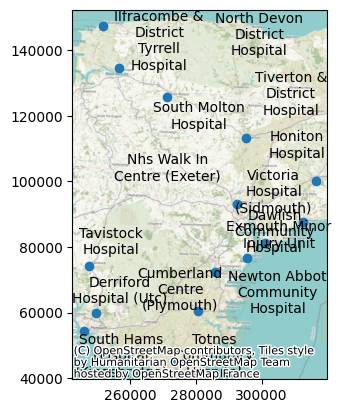

In [25]:
problem.plot_sites()

In [26]:
solution_greedy = problem.solve(p=len(problem.show_sites())-2, search_strategy="greedy")

C:\lokigi\lokigi\site.py:1414: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/13 [00:00<?, ?it/s]

Best combination for 1 sites: [np.int64(5)]
Best combination for 2 sites: [np.int64(5), np.int64(11)]
Best combination for 3 sites: [np.int64(0), np.int64(5), np.int64(11)]
Best combination for 4 sites: [np.int64(0), np.int64(5), np.int64(7), np.int64(11)]
Best combination for 5 sites: [np.int64(0), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 6 sites: [np.int64(0), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 7 sites: [np.int64(0), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 8 sites: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 9 sites: [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(11)]
Best combination for 10 sites: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.in

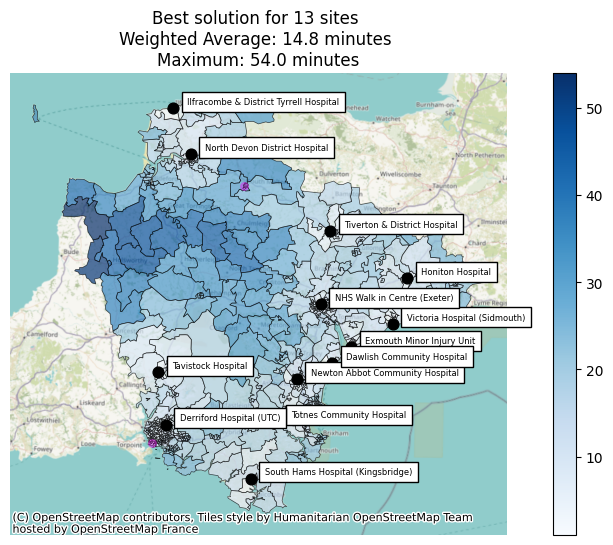

In [27]:
fig = solution_greedy.plot_best_combination(unchosen_site_colour="magenta")
fig;

:::{.callout-tip}
In this instance, we might want to consider the impact of boundary effects. We've only mapped the MIUs based in Devon. However, people on the border, where we are seeing extreme travel times, may well pass into a hospital in an adjoining county. 

If that's the case, we need to be sure we provide the OSM data for those regions when we do our initial travel time matrix generation, as otherwise the router won't be able to work out how to get there! If we just added an extra point in Cornwall to our travel matrix calculation as currently defined, we'd get 'NA' for all instances. 
:::

### Public Transport

Let's solve again for public transport times. 

In [28]:
problem_public_transport = SiteProblem()

problem_public_transport.add_sites(
    devon_mius_gdf,
    candidate_id_col="id"
    )

problem_public_transport.add_region_geometry_layer(
    lsoa_boundaries,
    common_col="LSOA11NM"
    )

problem_public_transport.add_travel_matrix(
    travel_matrix_df=travel_time_matrix_transit_wide,
    source_col="from_id",
    unit="minutes",
    )


In [29]:
solution_greedy_public_transport = problem_public_transport.solve(
    p=len(problem_public_transport.show_sites())-2,
    search_strategy="greedy"
    )

C:\lokigi\lokigi\site.py:1414: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/13 [00:00<?, ?it/s]

Best combination for 1 sites: [np.int64(7)]
Best combination for 2 sites: [np.int64(6), np.int64(7)]
Best combination for 3 sites: [np.int64(6), np.int64(7), np.int64(11)]
Best combination for 4 sites: [np.int64(6), np.int64(7), np.int64(11), np.int64(13)]
Best combination for 5 sites: [np.int64(1), np.int64(6), np.int64(7), np.int64(11), np.int64(13)]
Best combination for 6 sites: [np.int64(1), np.int64(6), np.int64(7), np.int64(11), np.int64(12), np.int64(13)]
Best combination for 7 sites: [np.int64(1), np.int64(6), np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(13)]
Best combination for 8 sites: [np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(13)]
Best combination for 9 sites: [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(11), np.int64(12), np.int64(13)]
Best combination for 10 sites: [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(9), np.int64(

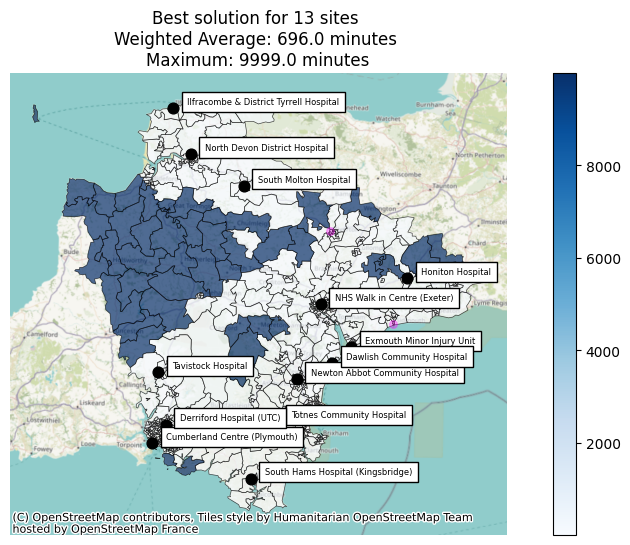

In [30]:
fig = solution_greedy_public_transport.plot_best_combination(unchosen_site_colour="magenta")
fig;

We can see that our output has some problems! 

First, we could try rerunning our public transport with 

- a higher maximum journey time
- a wider departure window
- a higher number of transfers 

## Tweaking a public transport travel matrix 

In [31]:
travel_time_matrix_transit = r5py.TravelTimeMatrix(
    transport_network,
    origins=devon_lsoas_with_coords_gdf,
    destinations=devon_mius_gdf,
    transport_modes=[r5py.TransportMode.TRANSIT],
    departure=datetime.datetime(2026, 4, 23, 14, 0, 0),
    max_time=datetime.timedelta(minutes=600),
    departure_time_window=datetime.timedelta(minutes=60),
    max_public_transport_rides=20
)

In [32]:
travel_time_matrix_transit_wide = travel_time_matrix_transit.pivot(columns="to_id", index="from_id", values="travel_time").reset_index()

We can check if there are any examples where you can't get to any hospital. 

In [33]:
len(travel_time_matrix_transit_wide)

707

In [34]:
travel_time_matrix_transit_wide_extended = travel_time_matrix_transit_wide.set_index("from_id").dropna(how="all").reset_index(drop=False)
travel_time_matrix_transit_wide_extended

to_id,from_id,Cumberland Centre (Plymouth),Dawlish Community Hospital,Derriford Hospital (UTC),Exmouth Minor Injury Unit,Honiton Hospital,Ilfracombe & District Tyrrell Hospital,NHS Walk in Centre (Exeter),Newton Abbot Community Hospital,North Devon District Hospital,South Hams Hospital (Kingsbridge),South Molton Hospital,Tavistock Hospital,Tiverton & District Hospital,Totnes Community Hospital,Victoria Hospital (Sidmouth)
0,East Devon 001A,260.0,217.0,268.0,211.0,76.0,365.0,137.0,213.0,288.0,292.0,245.0,316.0,190.0,259.0,160.0
1,East Devon 001B,359.0,288.0,363.0,258.0,133.0,518.0,223.0,302.0,490.0,NaN,433.0,415.0,317.0,326.0,198.0
2,East Devon 001C,398.0,377.0,402.0,338.0,216.0,543.0,294.0,386.0,515.0,NaN,458.0,454.0,388.0,361.0,260.0
3,East Devon 002A,222.0,197.0,225.0,127.0,14.0,365.0,116.0,205.0,288.0,286.0,241.0,275.0,184.0,213.0,72.0
4,East Devon 002B,221.0,195.0,223.0,128.0,18.0,365.0,115.0,201.0,288.0,282.0,241.0,275.0,180.0,209.0,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,West Devon 006D,97.0,244.0,56.0,240.0,262.0,314.0,172.0,222.0,268.0,184.0,308.0,45.0,248.0,184.0,252.0
703,West Devon 007A,150.0,285.0,111.0,283.0,307.0,331.0,217.0,287.0,285.0,255.0,353.0,61.0,293.0,252.0,297.0
704,West Devon 007B,150.0,285.0,111.0,283.0,307.0,331.0,217.0,287.0,285.0,255.0,353.0,61.0,293.0,252.0,297.0
705,West Devon 007C,130.0,293.0,90.0,301.0,308.0,408.0,249.0,262.0,331.0,221.0,443.0,80.0,329.0,223.0,306.0


In [35]:
len(travel_time_matrix_transit_wide_extended)

707

Let's agains set any NAs to a high value. 

In [36]:
travel_time_matrix_transit_wide_extended = travel_time_matrix_transit_wide_extended.fillna(9999.0)

And save this for future use.

In [37]:
travel_time_matrix_transit_wide_extended.to_csv("../../../sample_data/devon_miu_travel_matrix_public_transport_extended.csv", index=False)

We can then overwrite the existing travel matrix. 

In [38]:
problem_public_transport_extended = SiteProblem()

problem_public_transport_extended.add_sites(
    devon_mius_gdf,
    candidate_id_col="id"
    )

problem_public_transport_extended.add_region_geometry_layer(
    lsoa_boundaries,
    common_col="LSOA11NM"
    )

problem_public_transport_extended.add_travel_matrix(
    travel_matrix_df=travel_time_matrix_transit_wide_extended,
    source_col="from_id",
    unit="minutes",
    )


In [39]:
problem_public_transport_extended.show_travel_matrix()

to_id,from_id,Cumberland Centre (Plymouth),Dawlish Community Hospital,Derriford Hospital (UTC),Exmouth Minor Injury Unit,Honiton Hospital,Ilfracombe & District Tyrrell Hospital,NHS Walk in Centre (Exeter),Newton Abbot Community Hospital,North Devon District Hospital,South Hams Hospital (Kingsbridge),South Molton Hospital,Tavistock Hospital,Tiverton & District Hospital,Totnes Community Hospital,Victoria Hospital (Sidmouth)
0,East Devon 001A,260.0,217.0,268.0,211.0,76.0,365.0,137.0,213.0,288.0,292.0,245.0,316.0,190.0,259.0,160.0
1,East Devon 001B,359.0,288.0,363.0,258.0,133.0,518.0,223.0,302.0,490.0,9999.0,433.0,415.0,317.0,326.0,198.0
2,East Devon 001C,398.0,377.0,402.0,338.0,216.0,543.0,294.0,386.0,515.0,9999.0,458.0,454.0,388.0,361.0,260.0
3,East Devon 002A,222.0,197.0,225.0,127.0,14.0,365.0,116.0,205.0,288.0,286.0,241.0,275.0,184.0,213.0,72.0
4,East Devon 002B,221.0,195.0,223.0,128.0,18.0,365.0,115.0,201.0,288.0,282.0,241.0,275.0,180.0,209.0,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,West Devon 006D,97.0,244.0,56.0,240.0,262.0,314.0,172.0,222.0,268.0,184.0,308.0,45.0,248.0,184.0,252.0
703,West Devon 007A,150.0,285.0,111.0,283.0,307.0,331.0,217.0,287.0,285.0,255.0,353.0,61.0,293.0,252.0,297.0
704,West Devon 007B,150.0,285.0,111.0,283.0,307.0,331.0,217.0,287.0,285.0,255.0,353.0,61.0,293.0,252.0,297.0
705,West Devon 007C,130.0,293.0,90.0,301.0,308.0,408.0,249.0,262.0,331.0,221.0,443.0,80.0,329.0,223.0,306.0


And re-solve.

In [40]:
solution_greedy_public_transport_extended = problem_public_transport_extended.solve(
    p=len(problem_public_transport_extended.show_sites())-2,
    search_strategy="greedy"
    )

C:\lokigi\lokigi\site.py:1414: UserWarning: No demand data was provided. Demand from all regions has been assumed to be equal.If you wish to override this, run .add_demand() to add your site dataframe before running .solve() again.You can use the .show_demand_format() to see the expected format beforehand.
  warn(


  0%|          | 0/13 [00:00<?, ?it/s]

Best combination for 1 sites: [np.int64(7)]
Best combination for 2 sites: [np.int64(7), np.int64(11)]
Best combination for 3 sites: [np.int64(0), np.int64(7), np.int64(11)]
Best combination for 4 sites: [np.int64(0), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 5 sites: [np.int64(0), np.int64(1), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 6 sites: [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(11)]
Best combination for 7 sites: [np.int64(0), np.int64(1), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11)]
Best combination for 8 sites: [np.int64(0), np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(10), np.int64(11)]
Best combination for 9 sites: [np.int64(0), np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11)]
Best combination for 10 sites: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np

We can see that this time we get a much better output!

(Though some of these people may have had impossible journeys in a practical sense, taking over 4 hours and an unknown number of changes to get where they're going!)

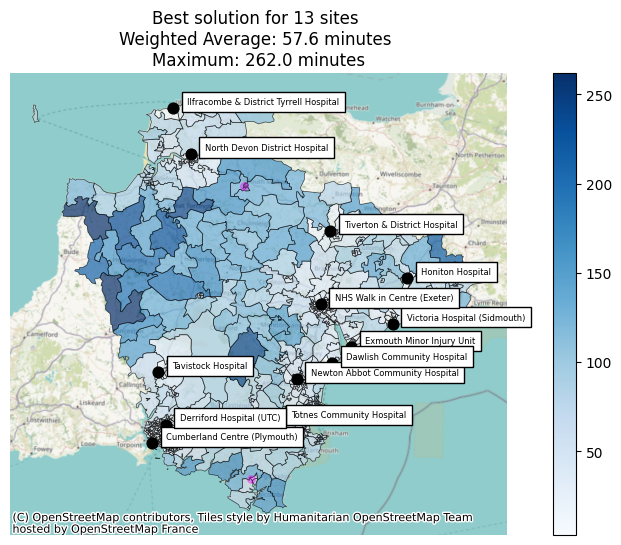

In [41]:
fig = solution_greedy_public_transport_extended.plot_best_combination(unchosen_site_colour="magenta")
fig;

:::{.callout-tip}
Lokigi will be extended in future to better handle NA values in travel matrices. 
:::

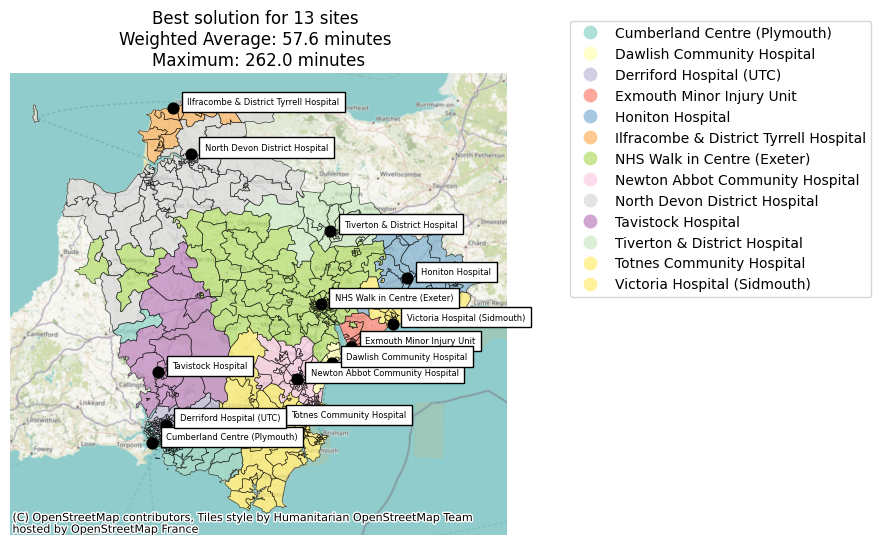

In [42]:
fig = solution_greedy_public_transport_extended.plot_best_combination(unchosen_site_colour="magenta", plot_site_allocation=True, legend_loc="lower right", show_all_locations=False, cmap="Set3")
fig;

In [43]:
solution_greedy_public_transport_extended.show_solutions().problem_df.iloc[0].selected_site.unique()

<StringArray>
[                      'Honiton Hospital',
           'Victoria Hospital (Sidmouth)',
            'NHS Walk in Centre (Exeter)',
              'Exmouth Minor Injury Unit',
           'Tiverton & District Hospital',
 'Ilfracombe & District Tyrrell Hospital',
          'North Devon District Hospital',
               'Derriford Hospital (UTC)',
           'Cumberland Centre (Plymouth)',
              'Totnes Community Hospital',
             'Dawlish Community Hospital',
        'Newton Abbot Community Hospital',
                     'Tavistock Hospital']
Length: 13, dtype: str

In [44]:
problem.show_sites()

,canonical_site_index,id,Latitude,Longitude,geometry
0,0,North Devon District Hospital,51.09217,-4.05043,POINT (256506.101 134540.134)
1,1,Honiton Hospital,50.79492,-3.18659,POINT (316466.043 100155.33)
2,2,Tiverton & District Hospital,50.90933,-3.49308,POINT (295122.857 113268.884)
3,3,Exmouth Minor Injury Unit,50.62083,-3.40198,POINT (300919.29 81063.23)
4,4,Victoria Hospital (Sidmouth),50.68161,-3.23966,POINT (312514.661 87617.001)
5,5,Newton Abbot Community Hospital,50.53926,-3.61224,POINT (285848.833 72295.946)
6,6,Totnes Community Hospital,50.43283,-3.68406,POINT (280491.309 60575.271)
7,7,NHS Walk in Centre (Exeter),50.72658,-3.52521,POINT (292444.533 92994.08)
8,8,Tavistock Hospital,50.54708,-4.15376,POINT (247503.629 74139.474)
9,9,South Hams Hospital (Kingsbridge),50.28929,-3.78143,POINT (273194.03 44777.085)


In [45]:
solution_greedy_public_transport_extended.show_solutions()

,site_names,site_indices,coverage_threshold,weighted_average,unweighted_average,90th_percentile,max,proportion_within_coverage_threshold,problem_df
0,"[North Devon District Hospital, Honiton Hospit...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 14]",None,57.65,57.65,98.4,262.0,0.0,from_id from_id_x North D...
